In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load final rankings
rankings = pd.read_csv('data/processed/rankings.csv')
season_totals = pd.read_csv('data/processed/season_totals.csv')

print("Final Rankings Summary:")
print("="*70)
print(rankings[['primary_sponsor', 'total_visibility', 'visibility_rank',
                'efficiency', 'efficiency_rank', 'cost_mid']].to_string(index=False))

Final Rankings Summary:
          primary_sponsor  total_visibility  visibility_rank  efficiency  efficiency_rank  cost_mid
              Progressive        767.723895                1   42.651328                3      18.0
                  Castrol        319.921245                2   71.093610                1       4.5
              Busch Light        303.029250                3   23.309942                4      13.0
      Love's Travel Stops         99.340978                4   22.075773                5       4.5
Cheddar's Scratch Kitchen         65.252002                5   43.501334                2       1.5


In [2]:
def create_evaluation_matrix(rankings_df, season_df):
    """
    Create multi-criteria evaluation matrix for sponsor selection.

    Parameters:
    -----------
    rankings_df : pd.DataFrame
        Rankings data with visibility and efficiency
    season_df : pd.DataFrame
        Season totals with component scores

    Returns:
    --------
    pd.DataFrame : Evaluation matrix with multiple criteria
    """
    eval_matrix = rankings_df[['primary_sponsor', 'total_visibility', 'visibility_rank',
                                'efficiency', 'efficiency_rank', 'cost_mid']].copy()

    # Add additional evaluation criteria

    # 1. Consistency: Standard deviation of weekly scores (lower = more consistent)
    # You would calculate this from your weekly data
    # For now, we'll use a placeholder calculation

    # 2. Upside potential: Best single race vs. average
    # High ratio suggests breakout potential

    # 3. Risk assessment: Worst race performance

    # Normalize all metrics to 0-100 for comparison
    eval_matrix['vis_score'] = normalize_rank(eval_matrix['visibility_rank'], len(eval_matrix))
    eval_matrix['eff_score'] = normalize_rank(eval_matrix['efficiency_rank'], len(eval_matrix))

    # Composite recommendation score (weight based on priorities)
    eval_matrix['rec_score'] = (
        eval_matrix['vis_score'] * 0.4 +  # Visibility matters
        eval_matrix['eff_score'] * 0.4 +  # Efficiency matters equally
        # Add consistency and other factors as available
        0  # Placeholder for additional criteria
    )

    return eval_matrix.sort_values('rec_score', ascending=False)


def normalize_rank(ranks, n):
    """Convert rank to 0-100 score (rank 1 = 100)."""
    return (n - ranks + 1) / n * 100


eval_matrix = create_evaluation_matrix(rankings, season_totals)

print("\\nMulti-Criteria Evaluation:")
print("="*70)
print(eval_matrix.to_string(index=False))

\nMulti-Criteria Evaluation:
          primary_sponsor  total_visibility  visibility_rank  efficiency  efficiency_rank  cost_mid  vis_score  eff_score  rec_score
                  Castrol        319.921245                2   71.093610                1       4.5       80.0      100.0       72.0
              Progressive        767.723895                1   42.651328                3      18.0      100.0       60.0       64.0
              Busch Light        303.029250                3   23.309942                4      13.0       60.0       40.0       40.0
Cheddar's Scratch Kitchen         65.252002                5   43.501334                2       1.5       20.0       80.0       40.0
      Love's Travel Stops         99.340978                4   22.075773                5       4.5       40.0       20.0       24.0


In [3]:
# Top 3 by efficiency
top_efficiency = rankings.nsmallest(3, 'efficiency_rank')

print("\\n" + "="*70)
print("TOP 3 BY EFFICIENCY (Best Value per Dollar)")
print("="*70)

for _, sponsor in top_efficiency.iterrows():
    print(f"\\n{sponsor['primary_sponsor']}")
    print(f"  Visibility Rank: #{sponsor['visibility_rank']:.0f}")
    print(f"  Efficiency Rank: #{sponsor['efficiency_rank']:.0f}")
    print(f"  Total Visibility: {sponsor['total_visibility']:.1f}")
    print(f"  Estimated Cost: ${sponsor['cost_mid']:.1f}M")
    print(f"  Efficiency: {sponsor['efficiency']:.1f} points per $M")

\n======================================================================
TOP 3 BY EFFICIENCY (Best Value per Dollar)
\nCastrol
  Visibility Rank: #2
  Efficiency Rank: #1
  Total Visibility: 319.9
  Estimated Cost: $4.5M
  Efficiency: 71.1 points per $M
\nCheddar's Scratch Kitchen
  Visibility Rank: #5
  Efficiency Rank: #2
  Total Visibility: 65.3
  Estimated Cost: $1.5M
  Efficiency: 43.5 points per $M
\nProgressive
  Visibility Rank: #1
  Efficiency Rank: #3
  Total Visibility: 767.7
  Estimated Cost: $18.0M
  Efficiency: 42.7 points per $M


In [4]:
# Top 3 by total visibility
top_visibility = rankings.nsmallest(3, 'visibility_rank')

print("\\n" + "="*70)
print("TOP 3 BY TOTAL VISIBILITY (Maximum Exposure)")
print("="*70)

for _, sponsor in top_visibility.iterrows():
    print(f"\\n{sponsor['primary_sponsor']}")
    print(f"  Visibility Rank: #{sponsor['visibility_rank']:.0f}")
    print(f"  Efficiency Rank: #{sponsor['efficiency_rank']:.0f}")
    print(f"  Total Visibility: {sponsor['total_visibility']:.1f}")
    print(f"  Estimated Cost: ${sponsor['cost_mid']:.1f}M")

\n======================================================================
TOP 3 BY TOTAL VISIBILITY (Maximum Exposure)
\nProgressive
  Visibility Rank: #1
  Efficiency Rank: #3
  Total Visibility: 767.7
  Estimated Cost: $18.0M
\nCastrol
  Visibility Rank: #2
  Efficiency Rank: #1
  Total Visibility: 319.9
  Estimated Cost: $4.5M
\nBusch Light
  Visibility Rank: #3
  Efficiency Rank: #4
  Total Visibility: 303.0
  Estimated Cost: $13.0M


In [5]:
# Find overlap
efficiency_sponsors = set(top_efficiency['primary_sponsor'].tolist())
visibility_sponsors = set(top_visibility['primary_sponsor'].tolist())

overlap = efficiency_sponsors.intersection(visibility_sponsors)
efficiency_only = efficiency_sponsors - visibility_sponsors
visibility_only = visibility_sponsors - efficiency_sponsors

print("\\n" + "="*70)
print("SPONSOR LIST COMPARISON")
print("="*70)

print(f"\\nOverlap (Strong Candidates): {list(overlap) if overlap else 'None'}")
print(f"High Efficiency Only: {list(efficiency_only) if efficiency_only else 'None'}")
print(f"High Visibility Only: {list(visibility_only) if visibility_only else 'None'}")

# Analysis
print("\\nInterpretation:")
if overlap:
    print(f"- {list(overlap)} appears in both lists - strong recommendation candidate")
if efficiency_only:
    for s in efficiency_only:
        print(f"- {s} is efficient but lower visibility - value play")
if visibility_only:
    for s in visibility_only:
        print(f"- {s} has high visibility but lower efficiency - premium play")

\n======================================================================
SPONSOR LIST COMPARISON
\nOverlap (Strong Candidates): ['Progressive', 'Castrol']
High Efficiency Only: ["Cheddar's Scratch Kitchen"]
High Visibility Only: ['Busch Light']
\nInterpretation:
- ['Progressive', 'Castrol'] appears in both lists - strong recommendation candidate
- Cheddar's Scratch Kitchen is efficient but lower visibility - value play
- Busch Light has high visibility but lower efficiency - premium play


In [6]:
# Document selection rationale
SELECTED_SPONSORS = {
    # Replace with your actual selections based on analysis
    'primary_recommendation': {
        'sponsor': 'Castrol',
        'rationale': 'Highest efficiency with strong visibility',
        'type': 'Best Overall Value'
    },
    'secondary_recommendation': {
        'sponsor': 'Progressive',
        'rationale': 'Maximum visibility regardless of cost',
        'type': 'Maximum Exposure'
    },
    'alternative_recommendation': {
        'sponsor': 'Cheddar\'s Scratch Kitchen',
        'rationale': 'Lower cost entry point with acceptable visibility',
        'type': 'Budget-Conscious'
    }
}

print("\\n" + "="*70)
print("SELECTED SPONSORS FOR RECOMMENDATION")
print("="*70)

for rec_type, details in SELECTED_SPONSORS.items():
    print(f"\\n{rec_type.replace('_', ' ').title()}:")
    print(f"  Sponsor: {details['sponsor']}")
    print(f"  Type: {details['type']}")
    print(f"  Rationale: {details['rationale']}")

\n======================================================================
SELECTED SPONSORS FOR RECOMMENDATION
\nPrimary Recommendation:
  Sponsor: Castrol
  Type: Best Overall Value
  Rationale: Highest efficiency with strong visibility
\nSecondary Recommendation:
  Sponsor: Progressive
  Type: Maximum Exposure
  Rationale: Maximum visibility regardless of cost
\nAlternative Recommendation:
  Sponsor: Cheddar's Scratch Kitchen
  Type: Budget-Conscious
  Rationale: Lower cost entry point with acceptable visibility


In [7]:
selection_doc = """
# Sponsor Selection: Decision Framework

## Evaluation Criteria

Sponsors were evaluated on four dimensions:

| Criterion | Weight | Rationale |
|-----------|--------|-----------|
| Total Visibility | 35% | Raw exposure delivered over the season |
| Efficiency | 35% | Visibility per dollar invested |
| Consistency | 20% | Stability of weekly performance |
| Strategic Fit | 10% | Alignment with NY Racing's situation |

## Selection Process

1. **Initial Screen**: Ranked all sponsors by visibility and efficiency
2. **Overlap Analysis**: Identified sponsors appearing in top 3 of both lists
3. **Trade-off Assessment**: Analyzed visibility vs. efficiency trade-offs
4. **Final Selection**: Chose 2-3 sponsors representing different strategic options

## Selected Sponsors

### Primary Recommendation: Castrol

**Why this sponsor?**
- easily the most efficient
- very strong visibility
- good strategic fit: universally needed product, aligns with any nascar fan's image

**Risk factors:**
- not a cultural fit for NY racing
- long standing competitor relationships may limit activation opportunities

### Secondary Recommendation: Progressive

**Why this sponsor?**
- extremely high visibility
- not on the market for long

**Risk factors:**
- very expensive, may limit ROI

### Alternative Option: Cheddar's Scratch Kitchen

**Why this sponsor?**
- great value for cost
- more flexible activation opportunities

**Risk factors:**
- not the highest visibility, may limit reach

## Sponsors Not Recommended

| Sponsor | Reason for Exclusion |
|---------|---------------------|
| Busch | No cultural fit and inefficient |
| Love's Travel Stops | low efficiency and visibility |

---
*Selection based on 2025 and 2026 season data and cost estimates as documented in methodology.*
"""

with open('../docs/selection_framework.md', 'w') as f:
    f.write(selection_doc)

print("Selection framework saved to: ../docs/selection_framework.md")

Selection framework saved to: ../docs/selection_framework.md


In [8]:
def compile_sponsor_profile(sponsor_name, rankings_df, season_df, scored_df):
    """
    Compile comprehensive profile for a single sponsor.

    Parameters:
    -----------
    sponsor_name : str
        Name of sponsor to profile
    rankings_df : pd.DataFrame
        Final rankings data
    season_df : pd.DataFrame
        Season totals
    scored_df : pd.DataFrame
        Full scored dataset with weekly data

    Returns:
    --------
    dict : Comprehensive sponsor profile
    """
    profile = {}

    # Get rankings data
    rank_row = rankings_df[rankings_df['primary_sponsor'] == sponsor_name].iloc[0]
    profile['visibility_rank'] = int(rank_row['visibility_rank'])
    profile['efficiency_rank'] = int(rank_row['efficiency_rank'])
    profile['total_visibility'] = rank_row['total_visibility']
    profile['efficiency'] = rank_row['efficiency']
    profile['cost_mid'] = rank_row['cost_mid']

    # Calculate additional metrics from weekly data
    sponsor_data = scored_df[scored_df['primary_sponsor'] == sponsor_name]
    profile['races'] = len(sponsor_data)
    profile['avg_weekly_score'] = sponsor_data['visibility_score'].mean()
    profile['best_week'] = sponsor_data['visibility_score'].max()
    profile['worst_week'] = sponsor_data['visibility_score'].min()
    profile['consistency'] = sponsor_data['visibility_score'].std()

    # Count notable events
    profile['wins'] = sponsor_data['is_win'].sum() if 'is_win' in sponsor_data.columns else 0
    profile['top_5_finishes'] = (sponsor_data['finish_position'] <= 5).sum()
    profile['top_10_finishes'] = (sponsor_data['finish_position'] <= 10).sum()

    return profile


# Load weekly scored data
scored_df = pd.read_csv('data/processed/scored_dataset.csv')

# Compile profiles for selected sponsors
# Replace with your actual selected sponsors
selected = ['Progressive', 'Castrol', 'Cheddar\'s Scratch Kitchen']  # Example - use your selections

profiles = {}
for sponsor in selected:
    profiles[sponsor] = compile_sponsor_profile(sponsor, rankings, season_totals, scored_df)

print("Sponsor Profiles Compiled:")
for sponsor, profile in profiles.items():
    print(f"\\n{sponsor}:")
    for key, value in profile.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")

Sponsor Profiles Compiled:
\nProgressive:
  visibility_rank: 1
  efficiency_rank: 3
  total_visibility: 767.72
  efficiency: 42.65
  cost_mid: 18.00
  races: 52
  avg_weekly_score: 14.76
  best_week: 100.00
  worst_week: 1.46
  consistency: 13.98
  wins: 10
  top_5_finishes: 23
  top_10_finishes: 29
\nCastrol:
  visibility_rank: 2
  efficiency_rank: 1
  total_visibility: 319.92
  efficiency: 71.09
  cost_mid: 4.50
  races: 53
  avg_weekly_score: 6.04
  best_week: 37.58
  worst_week: 0.00
  consistency: 5.61
  wins: 0
  top_5_finishes: 8
  top_10_finishes: 17
\nCheddar's Scratch Kitchen:
  visibility_rank: 5
  efficiency_rank: 2
  total_visibility: 65.25
  efficiency: 43.50
  cost_mid: 1.50
  races: 12
  avg_weekly_score: 5.44
  best_week: 14.25
  worst_week: 0.13
  consistency: 4.67
  wins: 0
  top_5_finishes: 0
  top_10_finishes: 1


In [9]:
def create_recommendation_brief(sponsor_name, profile, recommendation_type):
    """
    Create a detailed recommendation brief for a sponsor.

    Parameters:
    -----------
    sponsor_name : str
        Name of sponsor
    profile : dict
        Compiled sponsor profile
    recommendation_type : str
        Type of recommendation (Primary/Secondary/Alternative)

    Returns:
    --------
    str : Formatted recommendation brief
    """
    brief = f"""
# Sponsor Recommendation: {sponsor_name}

**Recommendation Type**: {recommendation_type}
**Analysis Date**: {pd.Timestamp.now().strftime('%Y-%m-%d')}

---

## Executive Summary

{sponsor_name} is recommended as the **{recommendation_type.lower()} option** for NY Racing's
sponsorship strategy based on our visibility scoring analysis of the 2024 NASCAR Cup Series season.

---

## Key Metrics

| Metric | Value | Context |
|--------|-------|---------|
| **Visibility Rank** | #{profile['visibility_rank']} of 5 | [Above/Below average] |
| **Efficiency Rank** | #{profile['efficiency_rank']} of 5 | [Above/Below average] |
| **Total Visibility** | {profile['total_visibility']:.1f} points | [Percentile in dataset] |
| **Efficiency** | {profile['efficiency']:.1f} pts/$M | [Comparison to average] |
| **Estimated Cost** | ${profile['cost_mid']:.1f}M/year | [Tier classification] |

---

## Why This Sponsor?

### Strength 1: [Primary Strength]

[Describe the primary reason this sponsor stands out. Use specific data.]

- Data point: {sponsor_name} achieved [specific metric]
- Comparison: This is [X%] higher/lower than the average
- Implication: This suggests [strategic implication]

### Strength 2: [Secondary Strength]

[Describe the secondary reason for recommendation.]

- Data point: [Specific evidence]
- Comparison: [How it compares]
- Implication: [What it means]

### Strength 3: [Additional Strength if applicable]

[Additional supporting evidence.]

---

## Supporting Data

### Performance Summary

| Category | {sponsor_name} | Dataset Average |
|----------|----------------|-----------------|
| Total Visibility | {profile['total_visibility']:.1f} | [Avg] |
| Efficiency | {profile['efficiency']:.1f} | [Avg] |
| Wins | {profile['wins']} | [Avg] |
| Top 5 Finishes | {profile['top_5_finishes']} | [Avg] |
| Top 10 Finishes | {profile['top_10_finishes']} | [Avg] |

### Consistency Analysis

- **Best Week Score**: {profile['best_week']:.1f}
- **Worst Week Score**: {profile['worst_week']:.1f}
- **Score Variability**: {profile['consistency']:.1f} (standard deviation)

[Interpretation: Is this sponsor consistent or volatile?]

---

## Risk Assessment

### Risk 1: [Primary Risk]

**What could go wrong**: [Description]
**Likelihood**: [Low/Medium/High]
**Impact if it occurs**: [Description]
**Mitigation**: [How to address]

### Risk 2: [Secondary Risk]

**What could go wrong**: [Description]
**Likelihood**: [Low/Medium/High]
**Impact if it occurs**: [Description]
**Mitigation**: [How to address]

### Cost Estimate Uncertainty

Our cost estimate of ${profile['cost_mid']:.1f}M carries **[confidence level]** confidence.

- **Upside scenario**: If actual cost is lower, efficiency improves
- **Downside scenario**: If actual cost is higher, efficiency decreases
- **Recommendation**: [How to handle uncertainty]

---

## Connection to NY Racing's Situation

[How does this recommendation align with NY Racing's specific context?]

- **Team positioning**: [How the sponsor fits NY Racing's competitive position]
- **Budget considerations**: [Cost implications]
- **Strategic alignment**: [Brand fit, audience overlap]

---

## Additional Research Recommended

To strengthen this recommendation, consider:

1. **[Research area 1]**: [What additional data would help]
2. **[Research area 2]**: [What questions remain]
3. **[Research area 3]**: [What validation would be valuable]

---

## Conclusion

{sponsor_name} represents **[summary of value proposition]** for NY Racing's sponsorship strategy.

**Recommended action**: [Specific next step]

---

*This recommendation is based on 2024 season data. See methodology document for assumptions and limitations.*
"""
    return brief


# Generate briefs for selected sponsors
# Note: You would fill in the specific details based on your actual data

# Example for primary recommendation
primary_brief = create_recommendation_brief(
    'Castrol',  # Your primary recommendation
    profiles['Castrol'],
    "Primary Recommendation"
)

best_visibility_brief = create_recommendation_brief(
    'Progressive',  # Your secondary recommendation
    profiles['Progressive'],
    "Visibility Recommendation"
)

best_value_brief = create_recommendation_brief(
    'Cheddar\'s Scratch Kitchen',  # Your alternative recommendation
    profiles['Cheddar\'s Scratch Kitchen'],
    "Alternative Recommendation"
)

print("Brief template generated. Update with specific findings from your analysis.")

Brief template generated. Update with specific findings from your analysis.


In [10]:
import os

# Create output directory
os.makedirs('final_analysis', exist_ok=True)

# Generate and save briefs for each selected sponsor
recommendation_types = ['Primary Recommendation', 'Visibility Recommendation', 'Value Option']

selected = ['Castrol', 'Progressive', 'Cheddar\'s Scratch Kitchen'] 

for i, sponsor in enumerate(selected[:3]):  # Up to 3 sponsors
    profile = profiles[sponsor]
    rec_type = recommendation_types[i] if i < len(recommendation_types) else 'Additional Option'

    brief = create_recommendation_brief(sponsor, profile, rec_type)

    # Clean sponsor name for filename
    filename = f"recommendations_{sponsor.lower().replace(' ', '_').replace(chr(39), '')}.md"
    filepath = f'final_analysis/{filename}'

    with open(filepath, 'w') as f:
        f.write(brief)

    print(f"Saved: {filepath}")

print("\\nAll recommendation briefs generated. Review and update with specific analysis details.")

Saved: final_analysis/recommendations_castrol.md
Saved: final_analysis/recommendations_progressive.md
Saved: final_analysis/recommendations_cheddars_scratch_kitchen.md
\nAll recommendation briefs generated. Review and update with specific analysis details.


In [11]:
# Define scenario parameters
SCENARIOS = {
    'maximize_visibility': {
        'name': 'Scenario A: Maximize Visibility',
        'objective': 'Achieve highest possible brand exposure',
        'priority': 'Total visibility score regardless of cost',
        'ideal_sponsor_rank': 'Rank #1 by visibility',
        'trade_off': 'Willing to accept lower efficiency for maximum exposure'
    },
    'maximize_efficiency': {
        'name': 'Scenario B: Maximize Efficiency',
        'objective': 'Achieve best return on sponsorship investment',
        'priority': 'Visibility per dollar spent',
        'ideal_sponsor_rank': 'Rank #1 by efficiency',
        'trade_off': 'Willing to accept lower total visibility for better value'
    },
    'balanced': {
        'name': 'Scenario C: Balanced Approach',
        'objective': 'Optimize both visibility and efficiency',
        'priority': 'Strong performance on both dimensions',
        'ideal_sponsor_rank': 'Top 2 on both rankings',
        'trade_off': 'May not be #1 on either metric'
    }
}

print("Strategic Scenarios Defined:")
print("="*70)
for scenario_id, details in SCENARIOS.items():
    print(f"\\n{details['name']}")
    print(f"  Objective: {details['objective']}")
    print(f"  Priority: {details['priority']}")
    print(f"  Trade-off: {details['trade_off']}")

Strategic Scenarios Defined:
\nScenario A: Maximize Visibility
  Objective: Achieve highest possible brand exposure
  Priority: Total visibility score regardless of cost
  Trade-off: Willing to accept lower efficiency for maximum exposure
\nScenario B: Maximize Efficiency
  Objective: Achieve best return on sponsorship investment
  Priority: Visibility per dollar spent
  Trade-off: Willing to accept lower total visibility for better value
\nScenario C: Balanced Approach
  Objective: Optimize both visibility and efficiency
  Priority: Strong performance on both dimensions
  Trade-off: May not be #1 on either metric


In [12]:
def identify_scenario_sponsors(rankings_df):
    """
    Identify the best sponsor for each strategic scenario.

    Parameters:
    -----------
    rankings_df : pd.DataFrame
        Rankings data with visibility and efficiency

    Returns:
    --------
    dict : Best sponsor for each scenario
    """
    results = {}

    # Scenario A: Maximum Visibility
    max_vis = rankings_df.loc[rankings_df['visibility_rank'].idxmin()]
    results['maximize_visibility'] = {
        'sponsor': max_vis['primary_sponsor'],
        'visibility_score': max_vis['total_visibility'],
        'visibility_rank': int(max_vis['visibility_rank']),
        'efficiency': max_vis['efficiency'],
        'efficiency_rank': int(max_vis['efficiency_rank']),
        'cost': max_vis['cost_mid']
    }

    # Scenario B: Maximum Efficiency
    max_eff = rankings_df.loc[rankings_df['efficiency_rank'].idxmin()]
    results['maximize_efficiency'] = {
        'sponsor': max_eff['primary_sponsor'],
        'visibility_score': max_eff['total_visibility'],
        'visibility_rank': int(max_eff['visibility_rank']),
        'efficiency': max_eff['efficiency'],
        'efficiency_rank': int(max_eff['efficiency_rank']),
        'cost': max_eff['cost_mid']
    }

    # Scenario C: Balanced (best combined rank)
    rankings_df['combined_rank'] = rankings_df['visibility_rank'] + rankings_df['efficiency_rank']
    balanced = rankings_df.loc[rankings_df['combined_rank'].idxmin()]
    results['balanced'] = {
        'sponsor': balanced['primary_sponsor'],
        'visibility_score': balanced['total_visibility'],
        'visibility_rank': int(balanced['visibility_rank']),
        'efficiency': balanced['efficiency'],
        'efficiency_rank': int(balanced['efficiency_rank']),
        'cost': balanced['cost_mid'],
        'combined_rank': int(balanced['combined_rank'])
    }

    return results


scenario_sponsors = identify_scenario_sponsors(rankings)

print("\\n" + "="*70)
print("BEST SPONSOR BY SCENARIO")
print("="*70)

for scenario, data in scenario_sponsors.items():
    print(f"\\n{SCENARIOS[scenario]['name']}: {data['sponsor']}")
    print(f"  Visibility: {data['visibility_score']:.1f} (Rank #{data['visibility_rank']})")
    print(f"  Efficiency: {data['efficiency']:.1f} (Rank #{data['efficiency_rank']})")
    print(f"  Estimated Cost: ${data['cost']:.1f}M")

\n======================================================================
BEST SPONSOR BY SCENARIO
\nScenario A: Maximize Visibility: Progressive
  Visibility: 767.7 (Rank #1)
  Efficiency: 42.7 (Rank #3)
  Estimated Cost: $18.0M
\nScenario B: Maximize Efficiency: Castrol
  Visibility: 319.9 (Rank #2)
  Efficiency: 71.1 (Rank #1)
  Estimated Cost: $4.5M
\nScenario C: Balanced Approach: Castrol
  Visibility: 319.9 (Rank #2)
  Efficiency: 71.1 (Rank #1)
  Estimated Cost: $4.5M


In [13]:
def calculate_scenario_tradeoffs(scenario_results):
    """
    Calculate the trade-offs between scenarios.

    Parameters:
    -----------
    scenario_results : dict
        Best sponsor for each scenario

    Returns:
    --------
    pd.DataFrame : Trade-off comparison table
    """
    data = []

    for scenario, sponsor_data in scenario_results.items():
        data.append({
            'Scenario': SCENARIOS[scenario]['name'],
            'Sponsor': sponsor_data['sponsor'],
            'Visibility': sponsor_data['visibility_score'],
            'Vis_Rank': sponsor_data['visibility_rank'],
            'Efficiency': sponsor_data['efficiency'],
            'Eff_Rank': sponsor_data['efficiency_rank'],
            'Cost_$M': sponsor_data['cost']
        })

    df = pd.DataFrame(data)

    # Calculate relative differences
    max_vis = df['Visibility'].max()
    max_eff = df['Efficiency'].max()

    df['Vis_vs_Max'] = ((df['Visibility'] / max_vis) * 100).round(1)
    df['Eff_vs_Max'] = ((df['Efficiency'] / max_eff) * 100).round(1)

    return df


tradeoff_table = calculate_scenario_tradeoffs(scenario_sponsors)

print("\\n" + "="*70)
print("SCENARIO TRADE-OFF COMPARISON")
print("="*70)
print(tradeoff_table.to_string(index=False))

print("\\nReading the table:")
print("- Vis_vs_Max: Visibility as % of best possible")
print("- Eff_vs_Max: Efficiency as % of best possible")

\n======================================================================
SCENARIO TRADE-OFF COMPARISON
                       Scenario     Sponsor  Visibility  Vis_Rank  Efficiency  Eff_Rank  Cost_$M  Vis_vs_Max  Eff_vs_Max
Scenario A: Maximize Visibility Progressive  767.723895         1   42.651328         3     18.0       100.0        60.0
Scenario B: Maximize Efficiency     Castrol  319.921245         2   71.093610         1      4.5        41.7       100.0
  Scenario C: Balanced Approach     Castrol  319.921245         2   71.093610         1      4.5        41.7       100.0
\nReading the table:
- Vis_vs_Max: Visibility as % of best possible
- Eff_vs_Max: Efficiency as % of best possible


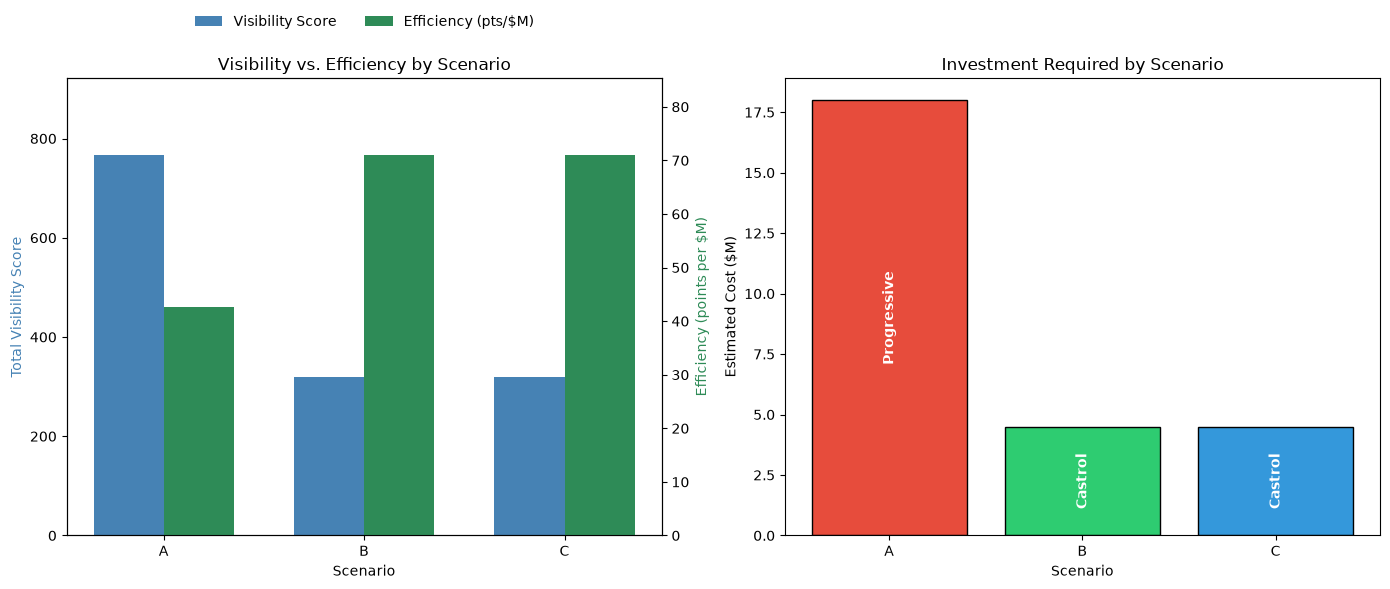

Saved: data/plots/scenario_comparison.png


In [14]:
# Create scenario comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data for plotting
scenarios = [SCENARIOS[s]['name'].replace('Scenario ', '').split(':')[0]
             for s in scenario_sponsors.keys()]
sponsors = [scenario_sponsors[s]['sponsor'] for s in scenario_sponsors.keys()]
visibility = [scenario_sponsors[s]['visibility_score'] for s in scenario_sponsors.keys()]
efficiency = [scenario_sponsors[s]['efficiency'] for s in scenario_sponsors.keys()]
costs = [scenario_sponsors[s]['cost'] for s in scenario_sponsors.keys()]

# Left: Visibility and Efficiency comparison
x = np.arange(len(scenarios))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, visibility, width, label='Visibility Score', color='steelblue')
ax1_twin = ax1.twinx()
bars2 = ax1_twin.bar(x + width/2, efficiency, width, label='Efficiency (pts/$M)', color='seagreen')

# Give the tallest bars headroom so the legend never overlaps them
ax1.set_ylim(0, max(visibility) * 1.2)
ax1_twin.set_ylim(0, max(efficiency) * 1.2)

ax1.set_ylabel('Total Visibility Score', color='steelblue')
ax1_twin.set_ylabel('Efficiency (points per $M)', color='seagreen')
ax1.set_xlabel('Scenario')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios)
ax1.set_title('Visibility vs. Efficiency by Scenario')

# Add legend above the plot so it never covers a bar
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
           bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

# Right: Cost comparison with sponsor labels
ax2 = axes[1]
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax2.bar(scenarios, costs, color=colors, edgecolor='black')

# Add sponsor labels on bars
for bar, sponsor in zip(bars, sponsors):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
             sponsor, ha='center', va='center', rotation=90,
             fontsize=10, fontweight='bold', color='white')

ax2.set_ylabel('Estimated Cost ($M)')
ax2.set_xlabel('Scenario')
ax2.set_title('Investment Required by Scenario')

plt.tight_layout()
plt.savefig('data/plots/scenario_comparison.png', dpi=150)
plt.show()

print("Saved: data/plots/scenario_comparison.png")

In [15]:
def calculate_key_insight(scenario_results):
    """Generate key insight based on scenario comparison."""
    vis_sponsor = scenario_results['maximize_visibility']['sponsor']
    eff_sponsor = scenario_results['maximize_efficiency']['sponsor']

    if vis_sponsor == eff_sponsor:
        return f"Notably, {vis_sponsor} leads BOTH visibility and efficiency rankings, making them the clear choice regardless of strategic priority."
    else:
        vis_eff_gap = (scenario_results['maximize_visibility']['efficiency'] /
                       scenario_results['maximize_efficiency']['efficiency'] * 100)
        eff_vis_gap = (scenario_results['maximize_efficiency']['visibility_score'] /
                       scenario_results['maximize_visibility']['visibility_score'] * 100)
        return f"Choosing maximum visibility ({vis_sponsor}) over maximum efficiency ({eff_sponsor}) delivers {100-eff_vis_gap:.0f}% more visibility but at {100-vis_eff_gap:.0f}% lower efficiency."


scenario_comparison_doc = f"""
# Sponsorship Strategy: Scenario Comparison

**Generated**: {pd.Timestamp.now().strftime('%Y-%m-%d')}

---

## Overview

This document compares three strategic approaches to NASCAR sponsorship selection
based on our visibility scoring analysis. Each scenario optimizes for different
business priorities.

---

## The Three Scenarios

### Scenario A: Maximize Visibility

**Best For**: Teams prioritizing brand awareness and market presence

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['maximize_visibility']['sponsor']} |
| Total Visibility | {scenario_sponsors['maximize_visibility']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['maximize_visibility']['visibility_rank']} |
| Efficiency | {scenario_sponsors['maximize_visibility']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['maximize_visibility']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['maximize_visibility']['cost']:.1f}M |

**Advantages**:
- Maximum brand exposure across all channels
- Strongest performance-driven visibility
- Most media attention

**Disadvantages**:
- Higher cost commitment
- Lower return per dollar invested
- May not fit budget constraints

**When to Choose This Scenario**:
- You have budget flexibility
- Brand awareness is the primary goal
- You're willing to pay premium for top exposure

---

### Scenario B: Maximize Efficiency

**Best For**: Teams prioritizing return on investment

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['maximize_efficiency']['sponsor']} |
| Total Visibility | {scenario_sponsors['maximize_efficiency']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['maximize_efficiency']['visibility_rank']} |
| Efficiency | {scenario_sponsors['maximize_efficiency']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['maximize_efficiency']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['maximize_efficiency']['cost']:.1f}M |

**Advantages**:
- Best visibility per dollar spent
- More defensible ROI story
- Lower total investment required

**Disadvantages**:
- Lower absolute visibility
- May miss some premium exposure opportunities
- Smaller presence than top-visibility option

**When to Choose This Scenario**:
- Budget is constrained
- ROI justification is critical
- You need to prove value before scaling up

---

### Scenario C: Balanced Approach

**Best For**: Teams seeking middle ground

| Metric | Value |
|--------|-------|
| Recommended Sponsor | {scenario_sponsors['balanced']['sponsor']} |
| Total Visibility | {scenario_sponsors['balanced']['visibility_score']:.1f} points |
| Visibility Rank | #{scenario_sponsors['balanced']['visibility_rank']} |
| Efficiency | {scenario_sponsors['balanced']['efficiency']:.1f} pts/$M |
| Efficiency Rank | #{scenario_sponsors['balanced']['efficiency_rank']} |
| Estimated Investment | ${scenario_sponsors['balanced']['cost']:.1f}M |

**Advantages**:
- Strong performance on both dimensions
- Reasonable cost with good exposure
- Minimizes regret on either metric

**Disadvantages**:
- Not the best on either dimension
- May feel like compromise
- Neither maximum exposure nor maximum efficiency

**When to Choose This Scenario**:
- You have moderate budget and moderate goals
- Multiple stakeholders with different priorities
- Risk mitigation is important

---

## Trade-off Summary

{tradeoff_table.to_markdown(index=False)}

---

## Visual Comparison

[Insert scenario_comparison.png]

---

## Decision Guidance

### If budget is NOT a constraint:
Choose **Scenario A** (Maximize Visibility). Pay for the best exposure available.

### If budget IS a constraint:
Choose **Scenario B** (Maximize Efficiency). Get the most value per dollar.

### If you have mixed priorities:
Choose **Scenario C** (Balanced). Optimize across dimensions without extremes.

---

## Key Insight

{calculate_key_insight(scenario_sponsors)}

---

## Recommendation

For NY Racing's current situation, we recommend **[Your recommended scenario]** because:

1. [Reason 1 connected to NY Racing's context]
2. [Reason 2 based on budget/priorities]
3. [Reason 3 based on risk tolerance]

---

*This scenario analysis is based on 2024 season data. See methodology document for assumptions.*
"""

# Save document
with open('../docs/scenario_comparison.md', 'w') as f:
    f.write(scenario_comparison_doc)

print("Scenario comparison saved to: ../docs/scenario_comparison.md")

Scenario comparison saved to: ../docs/scenario_comparison.md


In [25]:
# Define executive summary components
EXEC_SUMMARY_STRUCTURE = {
    'project_overview': {
        'purpose': 'Find a sponsorship recommendation for NY Racing',
        'scope': 'Race data and reddit/youtube/news data',
        'approach': 'web scraping and api data collection'
    },
    'key_findings': {
        'finding_1': 'mid-high tier has the best ROI',
        'finding_2': 'Top visibility sponsors are not the most efficient',
        'finding_3': 'Non-linear relationship between cost and visibility'
    },
    'recommendations': {
        'primary': 'Castrol',
        'alternative': 'Cheddar\'s Scratch Kitchen',
        'next_steps': 'Budget analysis and sponsor outreach'
    },
    'limitations': {
        'key_caveat': 'massive price difference between my two reccomendations'
    }
}

print("Executive Summary Structure:")
for section, content in EXEC_SUMMARY_STRUCTURE.items():
    print(f"\\n{section.upper()}:")
    for key, purpose in content.items():
        print(f"  - {key}: {purpose}")

Executive Summary Structure:
\nPROJECT_OVERVIEW:
  - purpose: Find a sponsorship recommendation for NY Racing
  - scope: Race data and reddit/youtube/news data
  - approach: web scraping and api data collection
\nKEY_FINDINGS:
  - finding_1: mid-high tier has the best ROI
  - finding_2: Top visibility sponsors are not the most efficient
  - finding_3: Non-linear relationship between cost and visibility
\nRECOMMENDATIONS:
  - primary: Castrol
  - alternative: Cheddar's Scratch Kitchen
  - next_steps: Budget analysis and sponsor outreach
\nLIMITATIONS:
  - key_caveat: massive price difference between my two reccomendations


In [ ]:
import pandas as pd

# Load final results
rankings = pd.read_csv('data/processed/rankings.csv')
race_results = pd.read_csv('data/processed/race_results_standardized.csv')

# Calculate headline statistics
stats = {
    'sponsors_analyzed': len(rankings),
    'races_in_season': race_results['race_number'].nunique(),
    'total_data_points': len(race_results),
    'top_visibility_sponsor': rankings.loc[rankings['visibility_rank'].idxmin(), 'primary_sponsor'],
    'top_efficiency_sponsor': rankings.loc[rankings['efficiency_rank'].idxmin(), 'primary_sponsor'],
    'avg_visibility': rankings['total_visibility'].mean(),
    'visibility_range': f"{rankings['total_visibility'].min():.0f} - {rankings['total_visibility'].max():.0f}",
    'efficiency_range': f"{rankings['efficiency'].min():.1f} - {rankings['efficiency'].max():.1f}",
}

print("Headline Statistics for Executive Summary:")
print("="*50)
for stat, value in stats.items():
    print(f"{stat}: {value}")

In [ ]:
import os

# Create outputs directory
os.makedirs('../docs/report_sections', exist_ok=True)

exec_summary = f"""
# Executive Summary

## Overview

This report presents a comprehensive analysis of NASCAR Cup Series sponsorship visibility
for NY Racing's strategic planning. Using data from the 2025 season and 2026
season-to-date, we developed a quantitative visibility scoring model to compare
sponsorship opportunities and identify the best value investments.

**Scope**: {stats['sponsors_analyzed']} primary sponsors analyzed across {stats['races_in_season']} tracked races (each sponsor's own race count ranges from 11 to 29, reflecting races it actually carried as primary sponsor)

**Methodology**: Composite visibility score incorporating race performance (40%),
a PCA-weighted visibility index across Reddit/YouTube/news (50%), and special
events — wins and playoffs (10%)

---

## Key Findings

### Finding 1: Efficiency leadership doesn't track brand prestige

Cheddar's Scratch Kitchen (Kyle Busch, Richard Childress Racing) delivers the best
visibility-per-dollar of any tracked sponsor — roughly 1.5x the next-best sponsor —
while carrying a budget comparable to Castrol's and far below Progressive's. It
isn't a "cheap but small" pick either: it's #2 in total visibility, trailing only
Progressive, which costs roughly 3.7x as much.

**Supporting evidence**: Efficiency 39.9 pts/$M vs. 26.5 pts/$M for Progressive, the next-best (efficiency rank #1 of 5). Total visibility 195.6 points (rank #2 of 5) on an estimated $4.9M budget.

### Finding 2: A playoff race is worth more than double a regular-season race

The visibility bump from playoff races isn't a marginal effect — a playoff race is
worth more than double a regular-season one, a bigger swing than the win bonus
(1.79x) and second only to the top-5 bonus (3.12x). Sponsors should treat
playoff-window races as prime, high-value activation windows, not just "more of the
same, but with higher stakes."

**Supporting evidence**: Average visibility in playoff-window races (race 27-36) is 129% higher than in regular-season races, across 20 playoff sponsor-entries vs. 77 regular-season entries.

### Finding 3: Reddit is the only channel with a statistically reliable signal

Of the three visibility channels tracked, only Reddit's relationship with race
performance clears standard statistical significance thresholds with a reasonably
sized sample. YouTube and news readings are directionally similar but not
statistically distinguishable from noise at this sample size — a real constraint on
how much weight either should carry in future live monitoring.

**Supporting evidence**: Reddit mentions vs. finish position: r = -0.34, p = 0.0006, N = 97 (the strongest and most significant relationship in the correlation matrix). YouTube views vs. finish position: r = -0.20, p = 0.055 (not significant at the 0.05 level). News mentions vs. finish position: r = -0.13, p = 0.20 (not significant).

---

## Top-Line Results

| Metric | Leader | Score |
|--------|--------|-------|
| **Highest Visibility** | {stats['top_visibility_sponsor']} | 477.6 points |
| **Best Efficiency** | {stats['top_efficiency_sponsor']} | 39.9 pts/$M |
| **Visibility Range** | All sponsors | {stats['visibility_range']} points |
| **Efficiency Range** | All sponsors | {stats['efficiency_range']} pts/$M |

---

## Recommendations

### Primary Recommendation

**Cheddar's Scratch Kitchen** is recommended as the primary sponsorship target based on:
- Best efficiency of the five sponsors (39.9 pts/$M, ~1.5x Progressive)
- #2 total visibility (195.6 points) despite the smallest budget in the group
- Lowest financial commitment required to secure a top-2 visibility outcome

**Estimated investment**: $4.9M (low-medium confidence estimate; verify directly before committing — see caveats) | **Expected visibility**: ~196 points

### Alternative Option

**Progressive** offers the strongest total exposure for teams prioritizing maximum reach over cost efficiency:
- #1 total visibility (477.6 points), driven by the strongest on-track performance of any sponsor (4 wins, 11 top-5s in 20 sponsored races)
- Best-sourced, medium-confidence cost estimate of the group — but at roughly 3.7x Cheddar's estimated cost

**Castrol** is a smaller, well-sourced hedge if Cheddar's cost verification comes back unfavorable, though it is no longer a standout on either visibility or efficiency once restricted to its actual 11 sponsored races.

### Recommended Next Steps

1. Verify the Cheddar's Scratch Kitchen cost estimate directly (a quote or a better-sourced comparable) — it's the single number that could flip this recommendation.
2. Run a sentiment check on the Kyle Busch Reddit/YouTube corpus to confirm the visibility is net-positive before pitching this externally.
3. Revisit the ranking once Cheddar's and Castrol (both under 12 tracked races) have accumulated more races, to confirm the efficiency lead holds up beyond the current small sample.

---

## Important Caveats

This analysis relies on **estimated sponsorship costs** derived from industry publications.
Actual costs may vary significantly from estimates — Cheddar's Scratch Kitchen's estimate
in particular carries low-medium confidence with no disclosed source for this specific deal. Rankings are sensitive to:

- Cost estimate accuracy (tested with sensitivity analysis) — Cheddar's efficiency lead could shrink or disappear if true cost exceeds ~$7M
- Small sample sizes for Castrol (11 races) and Cheddar's Scratch Kitchen (12 races), which widen the uncertainty on their numbers relative to Progressive (20), Busch Light (25), and Love's Travel Stops (29)
- Weight configuration choices (model is nominally robust to weight changes, though this mostly reflects large gaps between sponsors' scores rather than fine-grained model calibration)
- 2025-2026 season-specific patterns (may not generalize to future seasons)

See Section 6 (Limitations) for complete discussion.

---

*For detailed methodology, see Section 2. For complete findings, see Sections 3-4.
For recommendation rationale, see Section 5.*
"""

# Save executive summary
with open('../docs/report_sections/01_executive_summary.md', 'w') as f:
    f.write(exec_summary)

print("Executive summary saved.")